# Drug Consumption — Modèle Multi-Classe (Étape 1)

**Objectif :** Identifier la substance illicite principale consommée par un individu.

**Input  :** `prepared_data.pkl` généré par `nb_preparation.ipynb`

**Output :** `multiclass_model.pkl`

**Pipeline :**
```
prepared_data.pkl → nb_multiclass.ipynb → multiclass_model.pkl
                                                    ↓
                                                 app.py
```

## 0. Imports

In [11]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from collections import Counter

BLUE  = '#1F4E79'; LBLUE = '#2E75B6'; GREEN = '#1D9E75'
ORANGE= '#E8A838'; RED   = '#E24B4A'; LGRAY = '#F2F2F2'
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

## 1. Import de prepared_data.pkl

In [12]:
with open('../DATA_MODELE/prepared_data.pkl', 'rb') as f:
    prepared = pickle.load(f)

df           = prepared['df']               # DataFrame complet nettoyé
X_raw        = prepared['X_raw']            # Features (1877, 16)
FEATURE_COLS = prepared['feature_cols']     # Liste des 16 colonnes features

print(f'✅ prepared_data.pkl chargé')
print(f'   df shape     : {df.shape}')
print(f'   X_raw shape  : {X_raw.shape}')
print(f'   Features     : {FEATURE_COLS}')

✅ prepared_data.pkl chargé
   df shape     : (1877, 34)
   X_raw shape  : (1877, 16)
   Features     : ['age', 'gender', 'education', 'country', 'ethnicity', 'nscore', 'escore', 'oscore', 'ascore', 'cscore', 'impulsive', 'ss', 'alcohol_bin', 'caff_bin', 'choc_bin', 'nicotine_bin']


## 2. Construction de la cible multi-classe

Pour chaque individu on cherche **la substance illicite avec le niveau de consommation le plus élevé** (CL0→0 … CL6→6).

On ne garde que les individus avec au moins une consommation **récente (CL3+)** — les seuls pertinents pour le cas d'usage : *"quelqu'un arrive, il a pris quelque chose cette année, laquelle ?"*

In [13]:
# Substances illicites uniquement (nicotine exclue — déjà feature)
TARGET_ILLICIT = [
    'cannabis', 'benzos', 'ecstasy', 'amphet', 'coke', 'lsd',
    'mushrooms', 'legalh', 'amyl', 'meth', 'ketamine', 'heroin', 'vsa'
]

CL_ORDER = {'CL0': 0, 'CL1': 1, 'CL2': 2, 'CL3': 3, 'CL4': 4, 'CL5': 5, 'CL6': 6}

def get_primary_substance(row):
    scores = {s: CL_ORDER[row[s]] for s in TARGET_ILLICIT}
    return max(scores, key=scores.get)

def get_primary_score(row):
    return max(CL_ORDER[row[s]] for s in TARGET_ILLICIT)

df['primary_substance'] = df.apply(get_primary_substance, axis=1)
df['primary_score']     = df.apply(get_primary_score,     axis=1)

# Filtrage : consommateurs récents uniquement (CL3+)
df_recent = df[df['primary_score'] >= 3].copy().reset_index(drop=True)

print(f'Individus total              : {len(df)}')
print(f'Consommateurs récents (CL3+) : {len(df_recent)} ({len(df_recent)/len(df)*100:.1f}%)')
print()
print('Distribution des substances principales :')
print(df_recent['primary_substance'].value_counts())

Individus total              : 1877
Consommateurs récents (CL3+) : 1171 (62.4%)

Distribution des substances principales :
primary_substance
cannabis     789
benzos       145
amphet        52
legalh        42
meth          39
ecstasy       31
coke          20
lsd           16
mushrooms     10
vsa            7
ketamine       7
heroin         7
amyl           6
Name: count, dtype: int64


## 3. Visualisation du déséquilibre initial

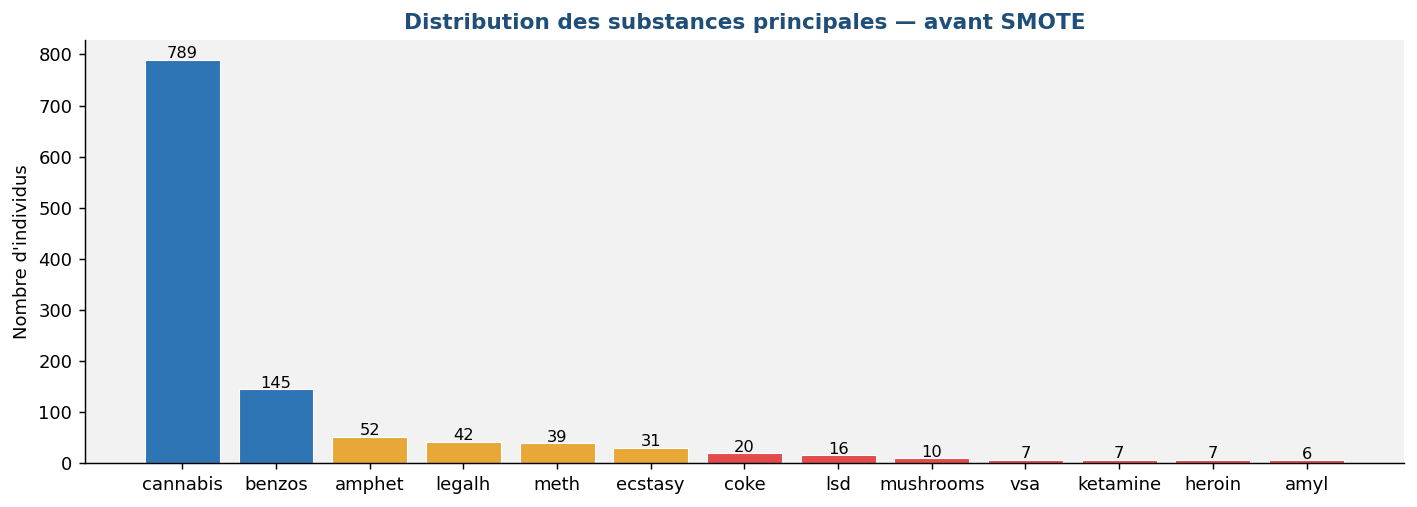

In [14]:
counts = df_recent['primary_substance'].value_counts()

fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = [LBLUE if v > 100 else ORANGE if v > 20 else RED for v in counts.values]
bars = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', linewidth=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', fontsize=9)
ax.set_title('Distribution des substances principales — avant SMOTE',
             fontweight='bold', color=BLUE, fontsize=12)
ax.set_ylabel("Nombre d'individus")
ax.set_facecolor(LGRAY)
plt.tight_layout()
plt.show()

## 4. Préparation X / y + rééquilibrage SMOTE

In [15]:
X = df_recent[FEATURE_COLS].values
y = df_recent['primary_substance'].values

print(f'Shape avant SMOTE : X={X.shape} | classes={len(np.unique(y))}')

# k_neighbors=3 pour les classes très rares (<5 individus)
smote        = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X, y)

print(f'Shape après SMOTE : X={X_res.shape}')
print('Distribution après SMOTE :')
for sub, count in sorted(Counter(y_res).items()):
    print(f'  {sub:<14} : {count}')

Shape avant SMOTE : X=(1171, 16) | classes=13
Shape après SMOTE : X=(10257, 16)
Distribution après SMOTE :
  amphet         : 789
  amyl           : 789
  benzos         : 789
  cannabis       : 789
  coke           : 789
  ecstasy        : 789
  heroin         : 789
  ketamine       : 789
  legalh         : 789
  lsd            : 789
  meth           : 789
  mushrooms      : 789
  vsa            : 789


## 5. GridSearchCV — Optimisation des hyperparamètres

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid={'n_estimators': [100, 200], 'max_depth': [5, 8, None]},
    cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_search.fit(X_res, y_res)

print(f'\nMeilleurs hyperparamètres : {grid_search.best_params_}')
print(f'Meilleur F1 macro (CV)    : {grid_search.best_score_:.3f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Meilleurs hyperparamètres : {'max_depth': None, 'n_estimators': 200}
Meilleur F1 macro (CV)    : 0.980


## 6. Entraînement final & métriques

In [17]:
best = grid_search.best_params_

rf_multi = RandomForestClassifier(
    n_estimators = best['n_estimators'],
    max_depth    = best['max_depth'],
    class_weight = 'balanced',
    random_state = 42
)
rf_multi.fit(X_res, y_res)

y_pred = cross_val_predict(rf_multi, X_res, y_res, cv=cv)

print(f'F1 macro   : {f1_score(y_res, y_pred, average="macro"):.3f}')
print(f'F1 weighted: {f1_score(y_res, y_pred, average="weighted"):.3f}')
print()
print(classification_report(y_res, y_pred))

F1 macro   : 0.980
F1 weighted: 0.980

              precision    recall  f1-score   support

      amphet       0.98      0.99      0.98       789
        amyl       1.00      1.00      1.00       789
      benzos       0.92      0.93      0.92       789
    cannabis       0.91      0.86      0.88       789
        coke       0.99      1.00      0.99       789
     ecstasy       0.99      0.99      0.99       789
      heroin       1.00      1.00      1.00       789
    ketamine       1.00      1.00      1.00       789
      legalh       0.99      0.99      0.99       789
         lsd       0.99      1.00      0.99       789
        meth       0.99      0.99      0.99       789
   mushrooms       0.99      1.00      1.00       789
         vsa       1.00      1.00      1.00       789

    accuracy                           0.98     10257
   macro avg       0.98      0.98      0.98     10257
weighted avg       0.98      0.98      0.98     10257



## 7. Matrice de confusion

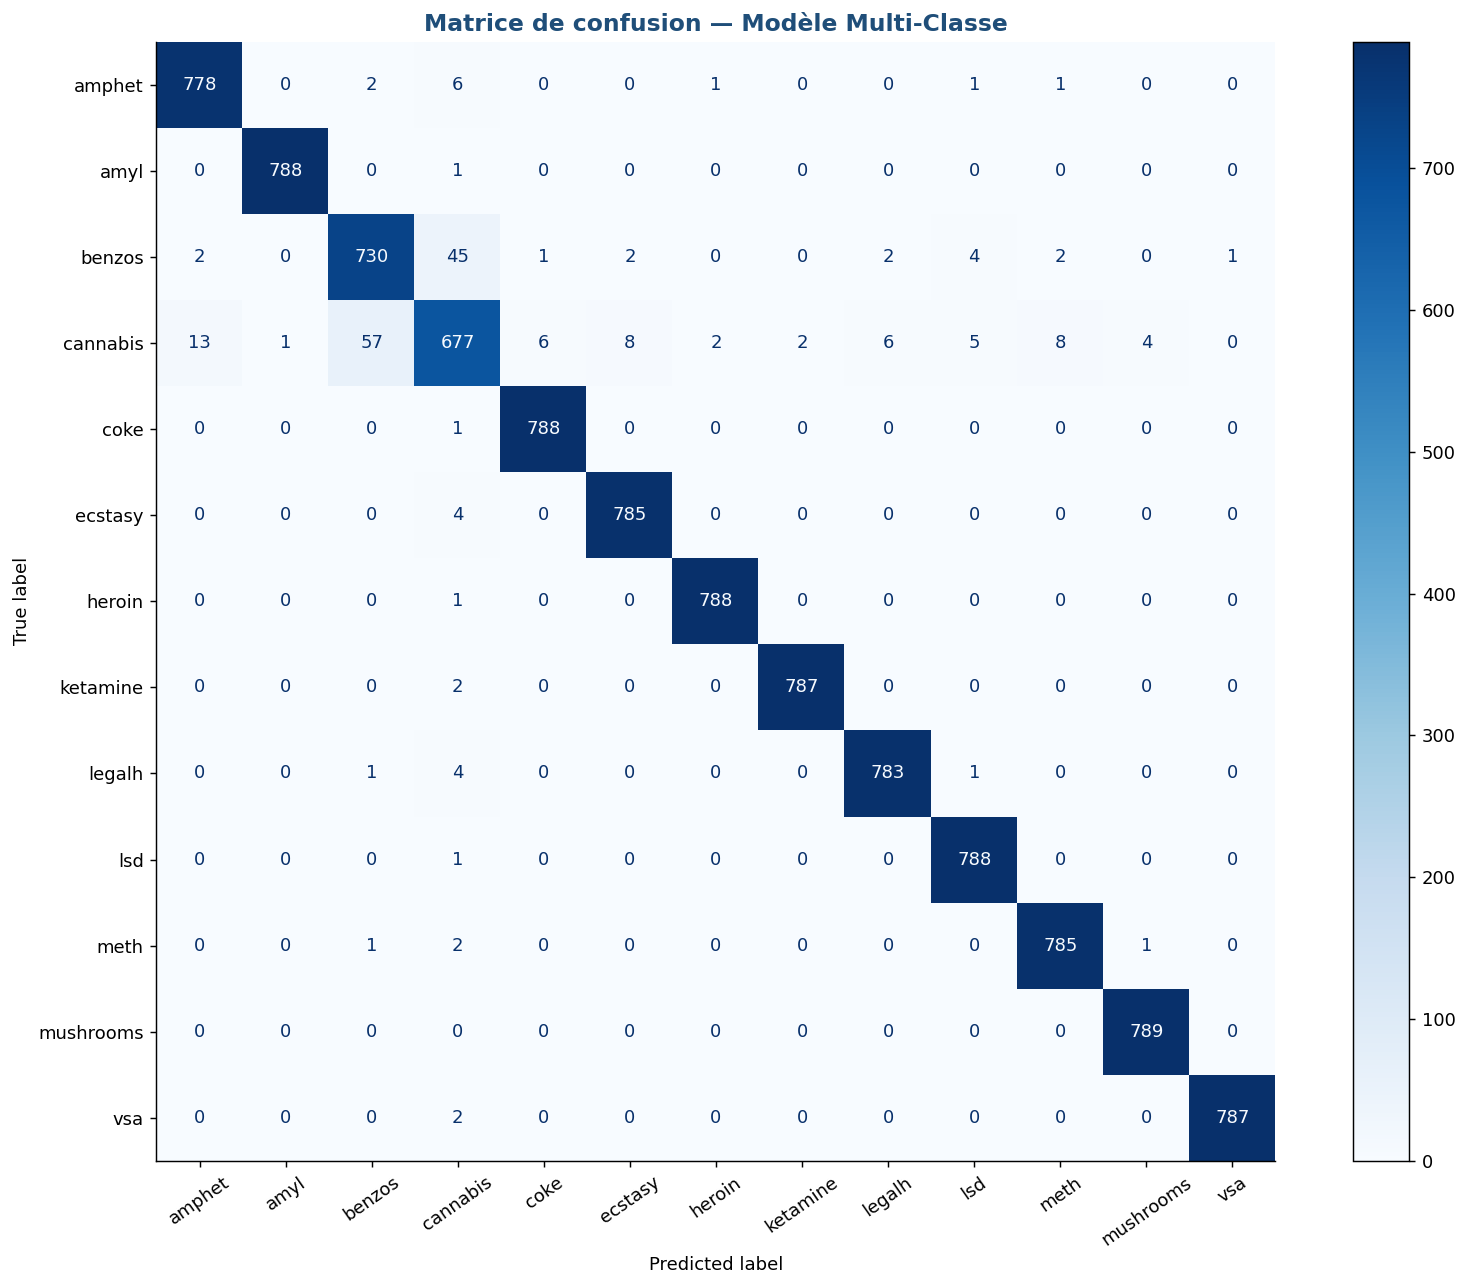

In [18]:
classes = rf_multi.classes_
cm      = confusion_matrix(y_res, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(13, 10))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(
    ax=ax, colorbar=True, cmap='Blues', xticks_rotation=35
)
ax.set_title('Matrice de confusion — Modèle Multi-Classe',
             fontweight='bold', color=BLUE, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Feature importances

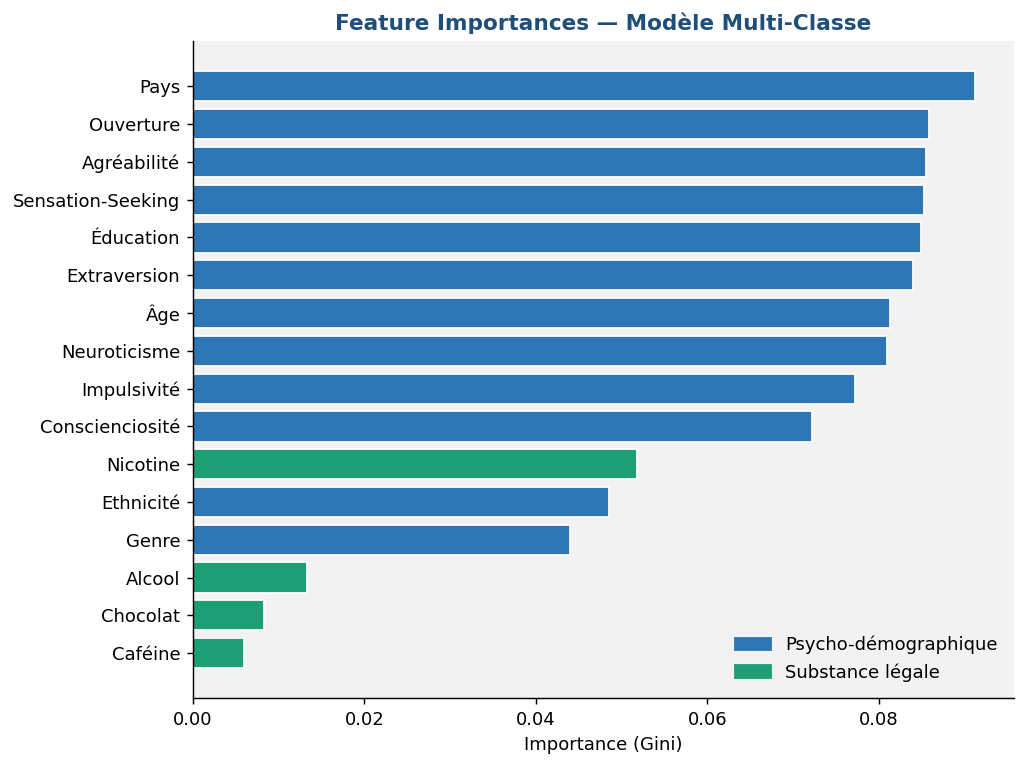

In [19]:
FEATURE_LABELS = {
    'age': 'Âge', 'gender': 'Genre', 'education': 'Éducation',
    'country': 'Pays', 'ethnicity': 'Ethnicité',
    'nscore': 'Neuroticisme', 'escore': 'Extraversion', 'oscore': 'Ouverture',
    'ascore': 'Agréabilité', 'cscore': 'Conscienciosité',
    'impulsive': 'Impulsivité', 'ss': 'Sensation-Seeking',
    'alcohol_bin': 'Alcool', 'caff_bin': 'Caféine',
    'choc_bin': 'Chocolat', 'nicotine_bin': 'Nicotine',
}

importances = rf_multi.feature_importances_
labels      = [FEATURE_LABELS[c] for c in FEATURE_COLS]
is_legal    = ['bin' in c for c in FEATURE_COLS]
idx_sorted  = np.argsort(importances)
colors_imp  = [GREEN if is_legal[i] else LBLUE for i in idx_sorted]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(np.array(labels)[idx_sorted], importances[idx_sorted],
        color=colors_imp, edgecolor='white')
ax.set_title('Feature Importances — Modèle Multi-Classe',
             fontweight='bold', color=BLUE, fontsize=12)
ax.set_xlabel('Importance (Gini)')
ax.set_facecolor(LGRAY)
p1 = mpatches.Patch(color=LBLUE, label='Psycho-démographique')
p2 = mpatches.Patch(color=GREEN, label='Substance légale')
ax.legend(handles=[p1, p2], frameon=False)
plt.tight_layout()
plt.show()

## 9. Export — multiclass_model.pkl

In [20]:
with open('../MODELE_SAVE/multiclass_model.pkl', 'wb') as f:
    pickle.dump({
        'model':            rf_multi,
        'classes':          rf_multi.classes_.tolist(),
        'feature_cols':     FEATURE_COLS,
        'feature_labels':   FEATURE_LABELS,
        'target_illicit':   TARGET_ILLICIT,
        'best_params':      best,
        'f1_macro':         f1_score(y_res, y_pred, average='macro'),
    }, f)

print('✅ multiclass_model.pkl exporté')
print(f'   Classes  : {rf_multi.classes_.tolist()}')
print(f'   F1 macro : {f1_score(y_res, y_pred, average="macro"):.3f}')
print(f'   Params   : {best}')

✅ multiclass_model.pkl exporté
   Classes  : ['amphet', 'amyl', 'benzos', 'cannabis', 'coke', 'ecstasy', 'heroin', 'ketamine', 'legalh', 'lsd', 'meth', 'mushrooms', 'vsa']
   F1 macro : 0.980
   Params   : {'max_depth': None, 'n_estimators': 200}
